In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Load
df = pd.read_csv('../data/gold_policy_clean.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df.date.min().date()} → {df.date.max().date()}')

# ITS sample — only rows where the outcome variable exists
its = df[df['domestic_premium'].notna()].copy()
print(f'\nITS sample: N={len(its)}')
print(f'  pre-hike  (post_hike=0): N={its["post_hike"].eq(0).sum()}')
print(f'  post-hike (post_hike=1): N={its["post_hike"].eq(1).sum()}')

# NW-94 rule: lag = ceil(0.75 × T^(1/3))
T = len(its)
NW_LAG = int(np.ceil(0.75 * T**(1/3)))
print(f'\nT={T}, NW lag={NW_LAG}')

Shape: (1160, 30)
Date range: 2022-01-03 → 2026-06-16

ITS sample: N=882
  pre-hike  (post_hike=0): N=859
  post-hike (post_hike=1): N=23

T=882, NW lag=8


In [2]:
# Ceiling = maximum duty-induced premium
its['ceiling'] = its['parity_pre'] * (0.09 / 1.06)

post = its[its['post_hike'] == 1]
pre  = its[its['post_hike'] == 0]

print('POST-HIKE WINDOW SUMMARY')
print('=' * 45)
print(f'N post-hike obs:          {len(post)}')
print(f'Mean domestic_premium:    ₹{post["domestic_premium"].mean():,.1f}')
print(f'Mean ceiling:             ₹{post["ceiling"].mean():,.1f}')
print(f'Naive pass-through:       {post["domestic_premium"].mean() / post["ceiling"].mean() * 100:.1f}%')

print('\nPRE-HIKE WINDOW SUMMARY')
print('=' * 45)
print(f'N pre-hike obs:           {len(pre)}')
print(f'Mean domestic_premium:    ₹{pre["domestic_premium"].mean():,.1f}')
print(f'Std domestic_premium:     ₹{pre["domestic_premium"].std():,.1f}')

print('\nSIGNAL-TO-NOISE CHECK')
print('=' * 45)
signal = post["domestic_premium"].mean() - pre["domestic_premium"].mean()
noise  = pre["domestic_premium"].std()
print(f'Signal (post mean − pre mean): ₹{signal:,.1f}')
print(f'Noise  (pre-period std):       ₹{noise:,.1f}')
print(f'Signal-to-noise ratio:         {signal/noise:.1f}x')

POST-HIKE WINDOW SUMMARY
N post-hike obs:          23
Mean domestic_premium:    ₹10,215.3
Mean ceiling:             ₹12,283.4
Naive pass-through:       83.2%

PRE-HIKE WINDOW SUMMARY
N pre-hike obs:           859
Mean domestic_premium:    ₹2,396.9
Std domestic_premium:     ₹2,540.8

SIGNAL-TO-NOISE CHECK
Signal (post mean − pre mean): ₹7,818.4
Noise  (pre-period std):       ₹2,540.8
Signal-to-noise ratio:         3.1x


In [3]:
# Low-duty window only (Jul 24 2024 – May 12 2026)
low_duty = its[(its['post_hike'] == 0) & (its['date'] >= '2024-07-24')]

print(f'Low-duty window: N={len(low_duty)}')
print(f'Mean premium:    ₹{low_duty["domestic_premium"].mean():,.1f}')
print(f'Std premium:     ₹{low_duty["domestic_premium"].std():,.1f}')

signal_honest = post["domestic_premium"].mean() - low_duty["domestic_premium"].mean()
noise_honest  = low_duty["domestic_premium"].std()
print(f'\nHonest signal:   ₹{signal_honest:,.1f}')
print(f'Honest noise:    ₹{noise_honest:,.1f}')
print(f'Honest SNR:      {signal_honest/noise_honest:.1f}x')

Low-duty window: N=360
Mean premium:    ₹-61.0
Std premium:     ₹1,770.8

Honest signal:   ₹10,276.4
Honest noise:    ₹1,770.8
Honest SNR:      5.8x


In [4]:
# Drop rows missing any regressor we'll need across all 3 models
its_clean = its[['date','domestic_premium','post_hike','t',
                  'delta_Gold_USD','delta_FX','ceiling']].dropna().copy()

print(f'Clean ITS sample after dropna: N={len(its_clean)}')

y  = its_clean['domestic_premium']
X1 = sm.add_constant(its_clean[['post_hike']])

m1 = sm.OLS(y, X1).fit()   # plain OLS for baseline

print(f'\nModel 1 — Baseline OLS (no controls, plain SE):')
print(f'  β₁ (post_hike): ₹{m1.params["post_hike"]:,.1f}')
print(f'  SE:             ₹{m1.bse["post_hike"]:,.1f}')
print(f'  p-value:        {m1.pvalues["post_hike"]:.2e}')
print(f'  R²:             {m1.rsquared:.3f}')
print(f'  N:              {int(m1.nobs)}')

Clean ITS sample after dropna: N=845

Model 1 — Baseline OLS (no controls, plain SE):
  β₁ (post_hike): ₹7,764.4
  SE:             ₹546.0
  p-value:        2.73e-41
  R²:             0.193
  N:              845


In [5]:
X2 = sm.add_constant(its_clean[['post_hike', 'delta_Gold_USD', 'delta_FX']])

m2 = sm.OLS(y, X2).fit(cov_type='HAC', cov_kwds={'maxlags': NW_LAG})

print(f'Model 2 — +Controls, NW lag={NW_LAG}:')
print(f'  β₁ (post_hike):     ₹{m2.params["post_hike"]:,.1f}')
print(f'  NW SE:              ₹{m2.bse["post_hike"]:,.1f}')
print(f'  p-value:            {m2.pvalues["post_hike"]:.2e}')
print(f'  β₃ (δGold_USD):     ₹{m2.params["delta_Gold_USD"]:,.1f}')
print(f'  β₄ (δFX):           ₹{m2.params["delta_FX"]:,.1f}')
print(f'  R²:                 {m2.rsquared:.3f}')

Model 2 — +Controls, NW lag=8:
  β₁ (post_hike):     ₹7,579.4
  NW SE:              ₹529.7
  p-value:            1.90e-46
  β₃ (δGold_USD):     ₹-541.2
  β₄ (δFX):           ₹-164.0
  R²:                 0.239


In [9]:
X3 = sm.add_constant(its_clean[['post_hike', 't', 'delta_Gold_USD', 'delta_FX']])

m3 = sm.OLS(y, X3).fit(cov_type='HAC', cov_kwds={'maxlags': NW_LAG})

print(f'Model 3 — MAIN SPEC, NW lag={NW_LAG}:')
print(f'  β₁ (post_hike):     ₹{m3.params["post_hike"]:,.1f}   ← HEADLINE')
print(f'  NW SE:              ₹{m3.bse["post_hike"]:,.1f}')
print(f'  95% CI:             [₹{m3.conf_int().loc["post_hike",0]:,.1f},  ₹{m3.conf_int().loc["post_hike",1]:,.1f}]')
print(f'  p-value:            {m3.pvalues["post_hike"]:.2e}')
print(f'  β₂ (trend):         {m3.params["t"]:,.3f}')
print(f'  β₃ (δGold_USD):     ₹{m3.params["delta_Gold_USD"]:,.1f}')
print(f'  β₄ (δFX):           ₹{m3.params["delta_FX"]:,.1f}')
print(f'  R²:                 {m3.rsquared:.3f}')
print(m3.summary())

Model 3 — MAIN SPEC, NW lag=8:
  β₁ (post_hike):     ₹10,107.0   ← HEADLINE
  NW SE:              ₹599.0
  95% CI:             [₹8,932.9,  ₹11,281.1]
  p-value:            7.18e-64
  β₂ (trend):         -4.426
  β₃ (δGold_USD):     ₹-473.6
  β₄ (δFX):           ₹-255.6
  R²:                 0.501
                            OLS Regression Results                            
Dep. Variable:       domestic_premium   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     79.25
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           4.60e-57
Time:                        00:40:50   Log-Likelihood:                -7616.1
No. Observations:                 845   AIC:                         1.524e+04
Df Residuals:                     840   BIC:                         1.527e+04
Df Model:                           4                                 

In [7]:
mean_ceiling = post['ceiling'].mean()
pass_through = m3.params['post_hike'] / mean_ceiling * 100

print(f'β₁:                 ₹{m3.params["post_hike"]:,.1f}')
print(f'Mean ceiling:       ₹{mean_ceiling:,.1f}')
print(f'Pass-through:       {pass_through:.1f}%')

β₁:                 ₹10,107.0
Mean ceiling:       ₹12,283.4
Pass-through:       82.3%


In [10]:
def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''

data = {
    'Specification':  ['Model 1 (Baseline)', f'Model 2 (+Controls, NW={NW_LAG})', f'Model 3 (Main spec, NW={NW_LAG})'],
    'β₁ post_hike':  [f'₹{m1.params["post_hike"]:,.1f}{stars(m1.pvalues["post_hike"])}',
                       f'₹{m2.params["post_hike"]:,.1f}{stars(m2.pvalues["post_hike"])}',
                       f'₹{m3.params["post_hike"]:,.1f}{stars(m3.pvalues["post_hike"])}'],
    'NW SE':         ['—', f'(₹{m2.bse["post_hike"]:,.1f})', f'(₹{m3.bse["post_hike"]:,.1f})'],
    'Controls':      ['None', 'δGold, δFX', 'δGold, δFX, trend'],
    'R²':            [f'{m1.rsquared:.3f}', f'{m2.rsquared:.3f}', f'{m3.rsquared:.3f}'],
    'N':             [int(m1.nobs), int(m2.nobs), int(m3.nobs)]
}

tbl = pd.DataFrame(data).set_index('Specification')
print('ITS REGRESSION TABLE')
print('Dependent variable: domestic_premium (₹/10g)')
print('*** p<0.001\n')
print(tbl.to_string())
print(f'\nPass-through (Model 3): {pass_through:.1f}% of mean duty ceiling (₹{mean_ceiling:,.0f})')

ITS REGRESSION TABLE
Dependent variable: domestic_premium (₹/10g)
*** p<0.001

                           β₁ post_hike     NW SE           Controls     R²    N
Specification                                                                   
Model 1 (Baseline)          ₹7,764.4***         —               None  0.193  845
Model 2 (+Controls, NW=8)   ₹7,579.4***  (₹529.7)         δGold, δFX  0.239  845
Model 3 (Main spec, NW=8)  ₹10,107.0***  (₹599.0)  δGold, δFX, trend  0.501  845

Pass-through (Model 3): 82.3% of mean duty ceiling (₹12,283)


In [11]:
lp_results = []

X_lp  = sm.add_constant(its_clean[['post_hike','t','delta_Gold_USD','delta_FX']]).reset_index(drop=True)
y_lp  = its_clean['domestic_premium'].reset_index(drop=True)

for h in range(31):
    y_h  = y_lp.shift(-h)                              # shift outcome forward by h
    mask = y_h.notna() & X_lp.notna().all(axis=1)
    
    if mask.sum() < 30:
        lp_results.append({'h': h, 'beta': np.nan, 'ci_lo': np.nan, 'ci_hi': np.nan})
        continue
    
    res = sm.OLS(y_h[mask], X_lp[mask]).fit(cov_type='HAC', cov_kwds={'maxlags': NW_LAG})
    ci  = res.conf_int().loc['post_hike']
    lp_results.append({'h': h,
                        'beta':  res.params['post_hike'],
                        'ci_lo': ci[0],
                        'ci_hi': ci[1],
                        'n':     mask.sum()})

lp = pd.DataFrame(lp_results)

# Print key horizons
print(f'{"h":>4}  {"β_h":>10}  {"CI lower":>10}  {"CI upper":>10}  {"PT%":>6}')
print('-' * 50)
for _, row in lp[lp['h'].isin([0,1,4,9,14,19,22])].iterrows():
    pt = row['beta'] / mean_ceiling * 100
    print(f'{int(row["h"]):>4}  {row["beta"]:>10,.1f}  {row["ci_lo"]:>10,.1f}  {row["ci_hi"]:>10,.1f}  {pt:>5.1f}%')

   h         β_h    CI lower    CI upper     PT%
--------------------------------------------------
   0    10,107.0     8,932.9    11,281.1   82.3%
   1    10,381.1     9,173.5    11,588.7   84.5%
   4    10,481.6     9,183.5    11,779.6   85.3%
   9    10,595.8     9,162.2    12,029.3   86.3%
  14    11,049.9     9,630.8    12,468.9   90.0%
  19     8,973.2     7,535.4    10,411.0   73.1%
  22        -0.0        -0.0        -0.0   -0.0%


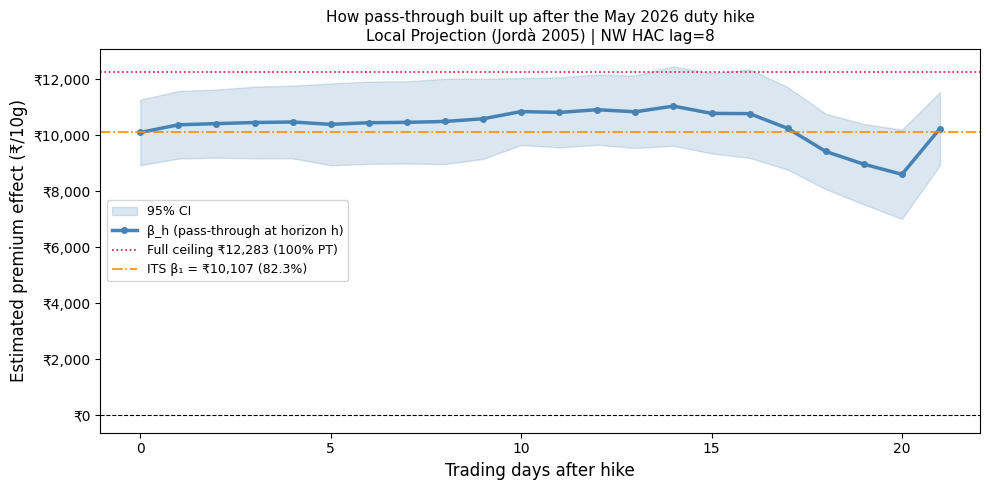

In [12]:
lp_plot = lp[(lp['beta'].notna()) & (lp['h'] <= 21)].copy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(lp_plot['h'], lp_plot['ci_lo'], lp_plot['ci_hi'],
                alpha=0.2, color='steelblue', label='95% CI')

ax.plot(lp_plot['h'], lp_plot['beta'],
        color='steelblue', linewidth=2.5,
        marker='o', markersize=4, label='β_h (pass-through at horizon h)')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(mean_ceiling, color='crimson', linewidth=1.2, linestyle=':',
           label=f'Full ceiling ₹{mean_ceiling:,.0f} (100% PT)')
ax.axhline(m3.params['post_hike'], color='darkorange', linewidth=1.2, linestyle='-.',
           label=f'ITS β₁ = ₹{m3.params["post_hike"]:,.0f} (82.3%)')

ax.set_xlabel('Trading days after hike', fontsize=12)
ax.set_ylabel('Estimated premium effect (₹/10g)', fontsize=12)
ax.set_title('How pass-through built up after the May 2026 duty hike\n'
             'Local Projection (Jordà 2005) | NW HAC lag=8', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../charts/fig_lp_impulse_response.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Final summary — TEST 03 & TEST 04
print('=' * 60)
print('TEST 03 — ITS MAIN TREATMENT EFFECT')
print('=' * 60)
print(f'  β₁:           ₹{m3.params["post_hike"]:,.1f}/10g')
print(f'  NW SE:        ₹{m3.bse["post_hike"]:,.1f}  (lag={NW_LAG})')
print(f'  95% CI:       [₹{m3.conf_int().loc["post_hike",0]:,.1f},  ₹{m3.conf_int().loc["post_hike",1]:,.1f}]')
print(f'  p-value:      {m3.pvalues["post_hike"]:.2e}')
print(f'  R²:           {m3.rsquared:.3f}')
print(f'  Pass-through: {pass_through:.1f}% of mean ceiling (₹{mean_ceiling:,.0f})')
print(f'  H₀ (β₁=0):   REJECTED')

print()
print('=' * 60)
print('TEST 04 — LOCAL PROJECTION (Jordà 2005)')
print('=' * 60)
print(f'  Reliable range: h=0..21 (h=22+ sample too small)')
print(f'  h=0  (Day 1):  ₹{lp.loc[lp.h==0,"beta"].values[0]:,.1f}  ({lp.loc[lp.h==0,"beta"].values[0]/mean_ceiling*100:.1f}%)')
print(f'  Peak at h=14:  ₹{lp.loc[lp.h==14,"beta"].values[0]:,.1f}  ({lp.loc[lp.h==14,"beta"].values[0]/mean_ceiling*100:.1f}%)')
print(f'  h=19 (Week 4): ₹{lp.loc[lp.h==19,"beta"].values[0]:,.1f}  ({lp.loc[lp.h==19,"beta"].values[0]/mean_ceiling*100:.1f}%)')
print(f'  CI excludes 0: throughout h=0..19')
print(f'  Chart saved:   charts/fig_lp_impulse_response.png')

TEST 03 — ITS MAIN TREATMENT EFFECT
  β₁:           ₹10,107.0/10g
  NW SE:        ₹599.0  (lag=8)
  95% CI:       [₹8,932.9,  ₹11,281.1]
  p-value:      7.18e-64
  R²:           0.501
  Pass-through: 82.3% of mean ceiling (₹12,283)
  H₀ (β₁=0):   REJECTED

TEST 04 — LOCAL PROJECTION (Jordà 2005)
  Reliable range: h=0..21 (h=22+ sample too small)
  h=0  (Day 1):  ₹10,107.0  (82.3%)
  Peak at h=14:  ₹11,049.9  (90.0%)
  h=19 (Week 4): ₹8,973.2  (73.1%)
  CI excludes 0: throughout h=0..19
  Chart saved:   charts/fig_lp_impulse_response.png


In [17]:
import statsmodels
print(f'statsmodels version: {statsmodels.__version__}')
print([m for m in dir(ardl_res) if not m.startswith('_')])

statsmodels version: 0.14.6
['aic', 'aicc', 'append', 'apply', 'ar_lags', 'arfreq', 'bic', 'bse', 'conf_int', 'cov_params', 'cov_params_default', 'data', 'df_model', 'df_resid', 'diagnostic_summary', 'f_test', 'fittedvalues', 'forecast', 'fpe', 'get_prediction', 'hqic', 'initialize', 'llf', 'load', 'model', 'nobs', 'normalized_cov_params', 'params', 'plot_diagnostics', 'plot_predict', 'predict', 'pvalues', 'remove_data', 'resid', 'roots', 'save', 'scale', 'sigma2', 'summary', 't_test', 't_test_pairwise', 'test_heteroskedasticity', 'test_normality', 'test_serial_correlation', 'tvalues', 'use_t', 'wald_test', 'wald_test_terms']


In [20]:
from statsmodels.tsa.ardl import ARDL, ardl_select_order, UECM

# Pre-hike window only
pre = df[df['post_hike'] == 0][['Gold_INR_PM', 'Gold_USD', 'rupees_per_dollar']].dropna()
print(f'Pre-hike sample for ARDL: N={len(pre)}')

# Step 1 — Select optimal lag order using AIC
sel = ardl_select_order(
    pre['Gold_INR_PM'],
    maxlag=8,
    exog=pre[['Gold_USD', 'rupees_per_dollar']],
    maxorder=4,
    ic='aic',
    trend='c'
)
print(f'AIC-selected order: {sel.model.ardl_order}')

# Step 2 — Fit ARDL model
ardl_res = sel.model.fit()

# Step 3 — Bounds test via UECM (bounds_test is a UECMResults method, not on ARDLResults)
uecm_res = UECM.from_ardl(sel.model).fit()
bt = uecm_res.bounds_test(case=3)
print(f'\nF-statistic:            {bt.stat:.3f}')
lo_95 = bt.crit_vals.loc[95.0, 'lower']
hi_95 = bt.crit_vals.loc[95.0, 'upper']

print(f'F-statistic: {bt.stat:.3f}')
print(f'95% bounds:  [{lo_95:.3f},  {hi_95:.3f}]')

if bt.stat > hi_95:
    print('Result: COINTEGRATION CONFIRMED (F > upper bound)')
elif bt.stat < lo_95:
    print('Result: NO COINTEGRATION (F < lower bound)')
else:
    print('Result: INCONCLUSIVE — F sits between I(0) and I(1) bounds')
    print('Cannot confirm or rule out cointegration at 95%')


Pre-hike sample for ARDL: N=859
AIC-selected order: (6, 4, 3)

F-statistic:            3.292
F-statistic: 3.292
95% bounds:  [3.229,  4.322]
Result: INCONCLUSIVE — F sits between I(0) and I(1) bounds
Cannot confirm or rule out cointegration at 95%
